In [1]:
import sys, types

# matplotlib-3.5.1-nspkg.pth pre-registers the system mpl_toolkits into
# sys.modules at Python startup — before any code runs.
# Clear it and redirect to the local compatible version.
for key in list(sys.modules):
    if key.startswith('mpl_toolkits'):
        del sys.modules[key]

_local = '/home/noah/.local/lib/python3.10/site-packages/mpl_toolkits'
m = types.ModuleType('mpl_toolkits')
m.__path__ = [_local]
sys.modules['mpl_toolkits'] = m

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import HTML
from numba import prange

print(f"matplotlib: {plt.matplotlib.__version__}  |  Axes3D: OK")

matplotlib: 3.10.9  |  Axes3D: OK


In [ ]:
#Helper functions
def plot_ring_cartesian(z, theta, name):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(theta, z, color='blue')

    ax.set_xlim(-np.pi, np.pi)
    ax.set_xticks([-np.pi, -3, -np.pi/2, -2, -1, 0, 1, 2, np.pi/2, 3, np.pi])
    ax.set_xticklabels(['-π', '-3', '-π/2', '-2', '-1', '0', '1', '2', 'π/2', '3', 'π'])
    ax.set_ylim(0, 2.0)
    ax.set_title(f'Firing rate of {name} around the ring')
    plt.tight_layout()
    plt.show()



def plot_z_vs_u(u_vals, z_vals):
    fig, ax = plt.subplots(figsize=(6, 6))
    pairs = sorted(zip(u_vals, z_vals))
    u_sorted, z_sorted = zip(*pairs)
    ax.plot(u_sorted, z_sorted, color='blue')
    ax.plot(u_vals, z_vals, color='blue')


    ax.set_title(f'z_max vs u')
    plt.tight_layout()
    plt.show()


def find_vel_avg(angles, activations):
    actv = activations.copy()

    x = np.sum(actv * np.cos(angles))
    y = np.sum(actv * np.sin(angles))
    goal_angle = np.arctan2(y, x)
    return np.array([np.cos(goal_angle), np.sin(goal_angle)])
    
def rand_link_func(y, sigma, inv_sqrt_n):
    out = np.empty_like(y)
    for i in prange(y.size):
        out[i] = np.random.normal(0.0, sigma) * inv_sqrt_n

    return out

def wrap_around(a1, a2):
    return (((a1-a2) + np.pi) % (2*np.pi)) - np.pi

def max_abs_eigenvalue(M):
    eigenvalues = np.linalg.eigvals(M)
    return np.max(np.abs(eigenvalues))

def cartesian_to_polar_3D(points):
    cpy = points.copy()

    for i in range(len(cpy)):
        x, y, z = cpy[i]
        r = np.sqrt(x**2 + y**2 + z**2)
        theta = np.arctan2(y, x)
        
        if r != 0.0:
            phi = np.arccos(z / r)
        else:
            phi = 0.0

        cpy[i] = r, theta, phi

    return cpy

def polar_to_cartesian_3D(points):
    cpy = points.copy()

    for i in range(len(cpy)):
        r, theta, phi = cpy[i]
        x = r * np.sin(phi) * np.cos(theta)
        y = r * np.sin(phi) * np.sin(theta)
        z = r * np.cos(phi)
        cpy[i] = x, y, z

    return cpy

#Assumes polar coordinates, will produce a logic error otherwise
def geodesic_distance(point1, point2):
    #Aka central angular distance
    alpha = np.arccos(np.clip(np.cos(point1[THETA]) * np.cos(point2[THETA]) + np.sin(point1[THETA]) * np.sin(point2[THETA]) * np.cos(point1[PHI] - point2[PHI])), -1, 1)
    return alpha

def plot_polar_points_3D(points, scalar_vals): 
    fig = plt.figure(figsize=(3, 3))
    ax = fig.add_subplot(111, projection='3d')

    pts = np.array(polar_to_cartesian_3D(points.copy()))
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=scalar_vals, cmap='Blues', vmin=-0.05, vmax=max(scalar_vals) , s=10)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)
    ax.set_box_aspect([1, 1, 1])

    
    plt.show()

# Mean-Field-Model RAN Extended to 3D

The goal is to extend a 2D mean field model ring attractor network (RAN) into a simple 3D version to be used on a crazyflie drone.

# Storing 3D RAN Nodes: Possible Methods

## Fibonacci Sphere

To represent a ring attractor in spherical coordinates, the Fibonacci Sphere will be used. This sphere generates nearly equidistant points on the surface of a sphere using the Golden Ratio and Fibonacci spirals. 

For $N$ points indexed $i = 0, 1, \ldots, N-1$:

$$z_i = 1 - \frac{2i}{N-1}$$

$$r_i = \sqrt{1 - z_i^2}$$

$$\theta_i = i \cdot \frac{2\pi}{\varphi^2}, \quad \text{where } \varphi = \frac{1 + \sqrt{5}}{2}$$

Then convert to Cartesian coordinates:

$$x_i = r_i \cos\theta_i, \qquad y_i = r_i \sin\theta_i, \qquad z_i = z_i$$

**Problem**: nodes are generated asymmetricly, which will create an uneven kernel matrix M. Nodes will not be equally spaced, and may cause heading tracking issues.


## Icosphere with Set Resolution

An icosphere is the only 3D sphere that can mathematically have equally-spaced points. It is recursively constructed using triangles. 

Start with 12 vertices and 20 faces on the base icosahedron. Each subdivision splits every triangle into 4, adding new vertices on each edge. The formula is:

$$N = 10 · 4^n + 2$$

E.g. 12, 42, 162, 642, etc

Now, when calculating the kernel matrix, all angular distances will be symmetrical like the 2D version.

Widget(value='<iframe src="http://localhost:33281/index.html?ui=P_0x726b0eb5b0d0_17&reconnect=auto" class="pyv…

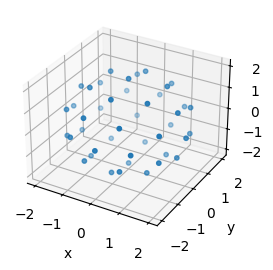

In [131]:
import pyvista as pv

# Create an icosphere with radius 2 and 2 levels of subdivision
icosphere_test = pv.Icosphere(radius=2.0, nsub=1)

# Visualize it immediately
icosphere_test .plot(show_edges=True, window_size=[300, 300])
fig = plt.figure(figsize=(3, 3))
ax = fig.add_subplot(111, projection='3d')

pts = icosphere_test.points
ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=10)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()


In [140]:
#Constants for indexing
X = MAG = 0
Y = PHI = 1     #phi = xy angle
Z = THETA = 2   #theta = z axis angle
QUALITY = 3

#Icosphere generation
nsub = 4 # 162 nodes
icosphere = pv.Icosphere(radius=1.0, nsub=nsub)

#Polar form of nodes [r, theta, phi], sphere points are not sorted/ordered
nodes = cartesian_to_polar_3D(icosphere.points.copy())

# print(nodes)

# Parameters
N_s   = 10 * 4**nsub +2
beta = 1.0
v = 0.5
dt = 0.1
sigma = 1.5
kappa = 20
u = 7.0

target1 = (2.0, -np.pi/2, np.pi/2, 5.0)   #distance, theta, phi, quality
targets = [target1]





In [138]:
#RAN Functions, all assume polar coordinates

def genetate_connection_matrix(sphere_points, J0, J):
    num_nodes = len(sphere_points)
    M = np.zeros((num_nodes, num_nodes))
    alphas = np.zeros((num_nodes, num_nodes))

    for i in range(num_nodes):
        for j in range(num_nodes):           
            alphas[i, j] = geodesic_distance(sphere_points[i], sphere_points[j])
            M[i, j] = J0 + J*np.cos(alphas[i,j])

    return alphas, M
_
def generate_sensory_input(sphere_points, targets, kappa):
    num_nodes = len(sphere_points)
    b = np.zeros(num_nodes)

    for j in range(len(targets)):
        for i in range(num_nodes):
            target_point = np.array((targets[j][MAG], targets[j][PHI], targets[j][THETA])) 
            alpha = geodesic_distance(sphere_points[i], target_point)
            b[i] += np.exp(kappa * (np.cos(alpha) - 1.0)) * targets[j][QUALITY]

    b *= (1/np.sqrt(num_nodes)) 
    return b

def generate_RAN_with_history(u_val, num_nodes, M, num_integrations, dt, sigma, beta, b, target_angles, target_qualities):
    # Static RAN run
    z      = np.zeros(num_nodes) 
    z_next = np.zeros(num_nodes)
    y      = np.zeros((num_integrations, num_nodes))
    
    for t in range(num_integrations):
        noise = rand_link_func(y[t], sigma * np.sqrt(dt), 1.0/np.sqrt(N_s))
        z = z + dt * (-z + np.tanh(u_val * (M @ z) + b - beta) - np.tanh(-beta) + noise) 
        y[t] = z

    return y

    


/tmp/ipykernel_44577/1118662425.py:83: RuntimeWarning: invalid value encountered in arccos
  alpha = np.arccos(np.cos(point1[THETA]) * np.cos(point2[THETA]) + np.sin(point1[THETA]) * np.sin(point2[THETA]) * np.cos(point1[PHI] - point2[PHI]))


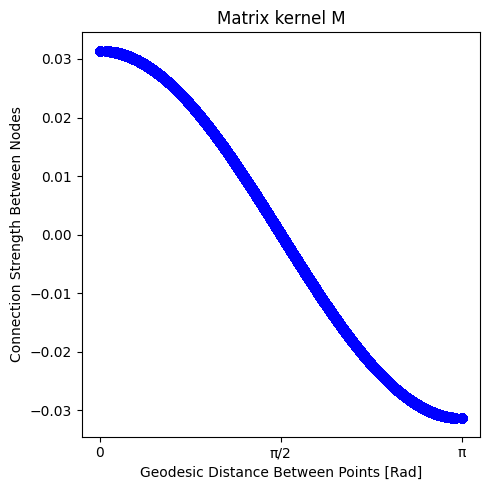

In [141]:
# Node positions and connectivity
alphas, M = genetate_connection_matrix(nodes, 0, np.pi/100)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(alphas, M, color='blue')

ax.set_xticks([0, np.pi/2, np.pi])
ax.set_xticklabels(['0', 'π/2', 'π'])
ax.set_title(f'Matrix kernel M')
ax.set_xlabel(f'Geodesic Distance Between Points [Rad]')
ax.set_ylabel(f'Connection Strength Between Nodes')
plt.tight_layout()
plt.show()

# plt.imshow(M, extent=[0, np.pi, 0, np.pi], cmap='bwr',origin='lower')
# plt.colorbar(label='m_ij')
# plt.show()

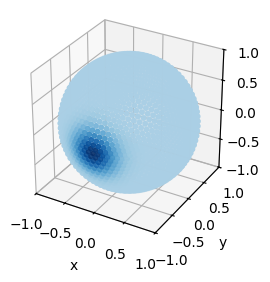

In [142]:
T = 200
b = generate_sensory_input(nodes, targets, kappa)
# y = generate_RAN_with_history(u, N_s, M, T, dt, sigma, beta, b, targets, gammas)
# z_final = y[-1]

# vel_vec_2D = find_vel_avg(theta, z_final)

# plot_ring_cartesian(b, theta, "b (external sensing)")
# plot_ring_cartesian(z_final, theta, "z (RAN dynamics)")
# plot_ring_polar(b, theta, "b (external sensing)")
# plot_ring_polar(z_final, theta, "z (RAN dynamics)")

# plt.figure(figsize=(8,5))
# plt.imshow(y.T, aspect='auto', origin='lower', cmap='viridis', extent=[0, T, -np.pi, np.pi])
# plt.colorbar(label='Neural Activation')

#plt.plot()

b_vis = []

for i in range(len(nodes)):
    b_vis.append((1, nodes[i][PHI], nodes[i][THETA]))



plot_polar_points_3D(b_vis, b)



In [136]:
# Static RAN run, with multiple u's
u_crit = 1/(max_abs_eigenvalue(M) * np.power((1/np.cosh(beta)),2))
u_crit = round(u_crit, 3)

print(max_abs_eigenvalue(M))
print(u_crit)


#u_vals = [u_crit, 1.0, 3.0, 5.0, 5.85, 7.0, 10.0, 15.0, 25.0]
u_vals = []
for i in range(0,25):
    u_vals.append(float(i))

z_vals = []
z_vals_max = []
b = generate_sensory_input(N_s, theta, kappa, targets, gammas)

for num in range(len(u_vals)):
    T      = 200
    y = generate_RAN_with_history(u_vals[num], N_s, M, T, dt, sigma, beta, b, targets, gammas)
    
    y[-1] = np.linalg.norm(y[-1])
    z_vals.append(y[-1])
    z_vals_max.append(float(np.max(y[-1])))
    
plot_z_vs_u(u_vals, z_vals)


LinAlgError: Array must not contain infs or NaNs